# Path Smoothing for Hockey Tracking Data

*Note*: I decided to use savitzky-golay filtering based on the ability to derive speed and acceleration as well as results here, though the raw data wasn't as bad as I initially thought. It was important to order my frames in the right way. Then pathing looked good with raw data. SavGol was still a useful tool and I kept it.

The raw 30 Hz position data from the tracking system is noisy — individual frame-to-frame positions jitter around the true path, producing thick, erratic lines when plotted. This notebook explores several classical smoothing algorithms to find the best approach for cleaning up player paths while preserving real skating motion (acceleration, turning, stopping).

**Algorithms compared:**
1. Rolling Mean (moving average)
2. Savitzky-Golay filter
3. Kalman filter (position + velocity state)
4. Gaussian kernel smoothing

**Evaluation metrics:**
- Total path length (raw vs smoothed)
- Frame-to-frame speed variance
- Mean squared deviation from raw path

In [1]:
import sys, warnings, importlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
import utils; importlib.reload(utils)
from utils import load_tracking

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d

try:
    from filterpy.kalman import KalmanFilter
    HAS_FILTERPY = True
    print('filterpy available')
except ImportError:
    HAS_FILTERPY = False
    print('filterpy not installed — Kalman cell will be skipped')

filterpy available


In [2]:
# preprocess.py has already handled frame ordering, imputation, and SavGol smoothing.
# tracking.parquet columns we care about:
#   raw_x, raw_y  — pre-smoothing positions (after imputation, before SavGol)
#   x, y          — SavGol-smoothed (wl=11, poly=2), already done by preprocess.py
#   frame_id      — monotone frame counter for correct temporal ordering

tracking = load_tracking('../data/tracking.parquet')
shifts   = pd.read_parquet('../data/shifts.parquet')
skaters  = tracking[tracking['Player or Puck'] == 'Player'].copy()

print(f'Skater rows: {len(skaters):,}')
print(f'Games: {skaters["Game"].nunique()}')

Skater rows: 7,441,848
Games: 10


In [3]:
# Pick a real shift (≥30 s) from shifts.parquet so we get a full skating sequence.
# Shifts store jersey numbers, tracking stores them in 'Player Jersey Number'.

def parse_mmss(s):
    try: m, sec = str(s).split(':'); return int(m)*60 + int(sec)
    except: return np.nan

shifts['shift_s'] = shifts['shift_length'].apply(parse_mmss)
shifts['start_s'] = shifts['start_clock'].apply(parse_mmss)
shifts['end_s']   = shifts['end_clock'].apply(parse_mmss)

long_shifts = shifts[
    (shifts['shift_s'] >= 30) &
    (shifts['Player_Id'] != 'Go') &
    (shifts['Player_Id'].str.isnumeric())
].reset_index(drop=True)

# Iterate to find first shift with actual tracking rows
RAW_EXAMPLE = pd.DataFrame()
CHOSEN_SHIFT = None
for idx in range(len(long_shifts)):
    sh = long_shifts.iloc[idx]
    game_key = f"{sh['Date']} {sh['Home_Team']} @ {sh['Away_Team']}"
    mask = (
        (skaters['Game']                             == game_key) &
        (skaters['Period_int']                       == sh['period']) &
        (skaters['Player Jersey Number'].astype(str) == str(sh['Player_Id'])) &
        (skaters['Clock_s']                          >= sh['end_s']) &
        (skaters['Clock_s']                          <= sh['start_s'])
    )
    candidate = skaters[mask].sort_values('frame_id')
    if len(candidate) >= 50:
        RAW_EXAMPLE = candidate.copy()
        CHOSEN_SHIFT = sh
        break

# --- Core analysis arrays ---
# raw_x/raw_y: pre-smoothing positions (imputed but not SavGol-filtered)
# x/y: already SavGol-smoothed by preprocess.py (wl=11, poly=2) — our baseline
fids         = RAW_EXAMPLE['frame_id'].values
t            = (fids - fids[0]) / 30.0        # relative time in seconds (~30 fps)
rx           = RAW_EXAMPLE['raw_x'].values
ry           = RAW_EXAMPLE['raw_y'].values
sx_savgol_pp = RAW_EXAMPLE['x'].values         # preprocess.py SavGol baseline
sy_savgol_pp = RAW_EXAMPLE['y'].values

dt_med         = 1 / 30.0
dist_per_frame = np.sqrt(np.diff(rx)**2 + np.diff(ry)**2)

pad  = 15
xlim = (rx.min() - pad, rx.max() + pad)
ylim = (ry.min() - pad, ry.max() + pad)

print(f"Player #{CHOSEN_SHIFT['Player_Id']},  {CHOSEN_SHIFT['shift_length']} shift")
print(f"  Game: {game_key}  | Period {CHOSEN_SHIFT['period']}  | {CHOSEN_SHIFT['start_clock']} → {CHOSEN_SHIFT['end_clock']}")
print(f"  {len(RAW_EXAMPLE)} frames  |  X=[{rx.min():.1f}, {rx.max():.1f}]  Y=[{ry.min():.1f}, {ry.max():.1f}]")
print(f"  dist/frame: mean={dist_per_frame.mean():.3f} ft,  std={dist_per_frame.std():.3f} ft,  max={dist_per_frame.max():.3f} ft")

Player #29,  00:55 shift
  Game: 2025-10-11 Team D @ Team A  | Period 1  | 20:00 → 19:05
  1499 frames  |  X=[-85.4, 79.3]  Y=[-40.2, 42.5]
  dist/frame: mean=0.565 ft,  std=1.229 ft,  max=46.629 ft


## Baseline: Raw Path Visualization

Before smoothing, let's plot the raw X and Y signals over time, plus the 2D path on a rink zoomed into the action area. This gives us a clear sense of how much noise we're dealing with.

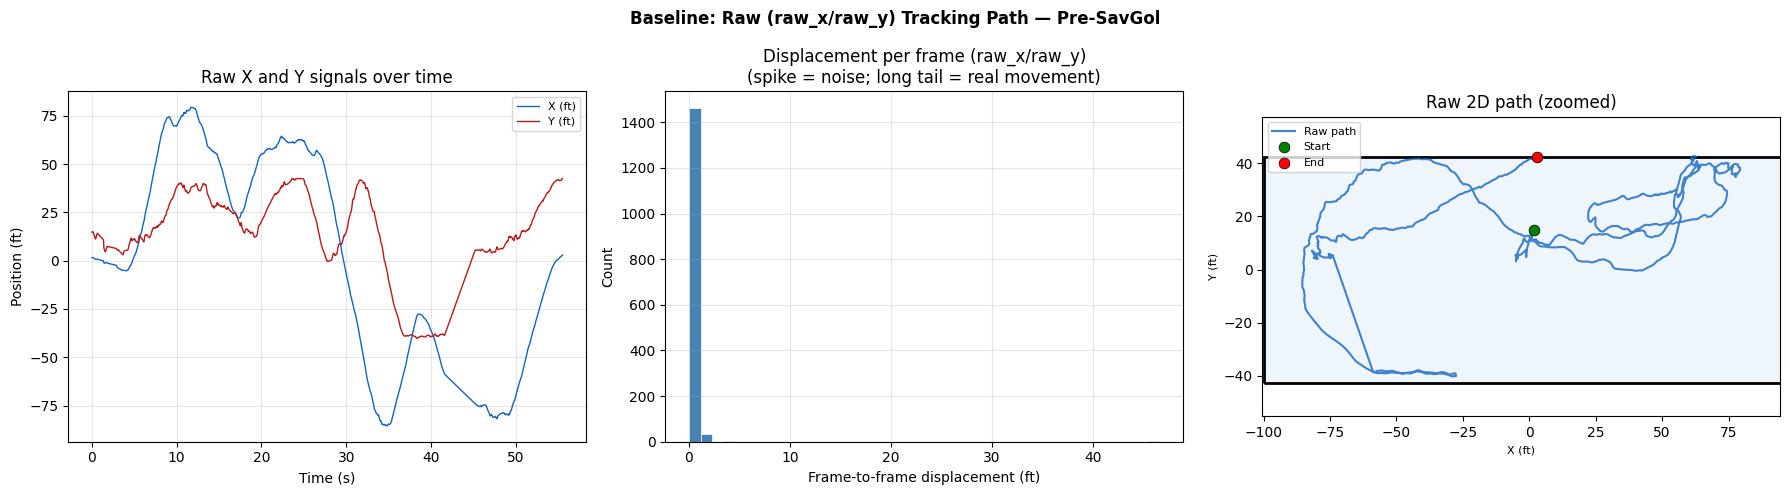

In [4]:
def draw_rink_mini(ax, xlim=None, ylim=None):
    """Boards outline only — no zone lines or circles."""
    ax.add_patch(Rectangle((-100,-42.5),200,85,color='#eef6fc',zorder=0))
    ax.add_patch(Rectangle((-100,-42.5),200,85,lw=2,edgecolor='black',facecolor='none',zorder=1))
    ax.set_aspect('equal')
    ax.set_xlabel('X (ft)', fontsize=8)
    ax.set_ylabel('Y (ft)', fontsize=8)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    else: ax.set_xlim(-106,106); ax.set_ylim(-46,46)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Raw X/Y over time
axes[0].plot(t, rx, color='#1565C0', lw=1, label='X (ft)')
axes[0].plot(t, ry, color='#B71C1C', lw=1, label='Y (ft)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Position (ft)')
axes[0].set_title('Raw X and Y signals over time')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 2. Frame-to-frame displacement distribution
axes[1].hist(dist_per_frame, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Frame-to-frame displacement (ft)'); axes[1].set_ylabel('Count')
axes[1].set_title('Displacement per frame (raw_x/raw_y)\n(spike = noise; long tail = real movement)')
axes[1].grid(alpha=0.3)

# 3. 2D path on rink (zoomed)
draw_rink_mini(axes[2], xlim=xlim, ylim=ylim)
axes[2].plot(rx, ry, color='#1565C0', lw=1.5, alpha=0.8, label='Raw path')
axes[2].scatter(rx[0], ry[0], s=60, color='green', ec='black', lw=0.5, zorder=5, label='Start')
axes[2].scatter(rx[-1], ry[-1], s=60, color='red', ec='black', lw=0.5, zorder=5, label='End')
axes[2].legend(fontsize=8)
axes[2].set_title('Raw 2D path (zoomed)')

plt.suptitle('Baseline: Raw (raw_x/raw_y) Tracking Path — Pre-SavGol', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Algorithm 1: Rolling Mean (Moving Average)

The simplest approach — average the last N frames. Fast and easy, but introduces **lag** (the smoothed path trails behind the true position) and can't handle gaps. Good enough for visualization but blunts sharp turns.

**Window sizes:** 3, 5, 10 frames → at 30 Hz that's 0.1 s, 0.17 s, 0.33 s of history.  
Using `center=True` makes it symmetric (no lag), at the cost of needing future frames.

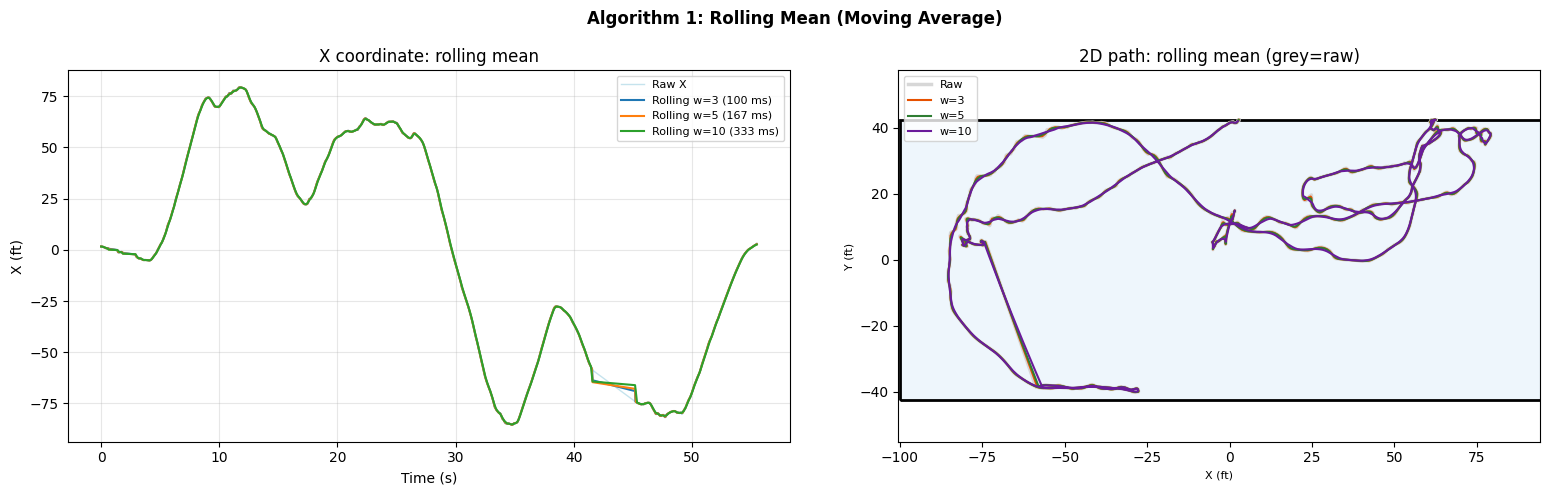

In [5]:
def rolling_mean(arr, w):
    return pd.Series(arr).rolling(w, min_periods=1, center=True).mean().values

ROLLING_WINDOWS = [3, 5, 10]
rolling_results = {w: (rolling_mean(rx, w), rolling_mean(ry, w)) for w in ROLLING_WINDOWS}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(t, rx, color='lightblue', lw=1, alpha=0.7, label='Raw X')
for w, (sx, sy) in rolling_results.items():
    axes[0].plot(t, sx, lw=1.5, label=f'Rolling w={w} ({w/30*1000:.0f} ms)')
axes[0].set_title('X coordinate: rolling mean'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('X (ft)')

draw_rink_mini(axes[1], xlim=xlim, ylim=ylim)
axes[1].plot(rx, ry, color='lightgrey', lw=2.5, alpha=0.9, label='Raw', zorder=3)
for (w, (sx, sy)), col in zip(rolling_results.items(), ['#E65100', '#2E7D32', '#6A1B9A']):
    axes[1].plot(sx, sy, color=col, lw=1.5, label=f'w={w}', zorder=5)
axes[1].legend(fontsize=8); axes[1].set_title('2D path: rolling mean (grey=raw)')

plt.suptitle('Algorithm 1: Rolling Mean (Moving Average)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Algorithm 2: Savitzky-Golay Filter

Fits a polynomial to a sliding window of frames — preserves peaks and direction changes much better than a simple average. Already used in `preprocess.py` for **speed**, but not applied to X/Y positions directly.

**Parameters:**
- `window_length` — must be odd, in frames (at 30 Hz: 7 = 0.23 s, 15 = 0.5 s)
- `polyorder` — polynomial degree (2 = quadratic, 3 = cubic)

Higher `polyorder` tracks sharper turns but adds more edge noise. Longer `window_length` smooths more.

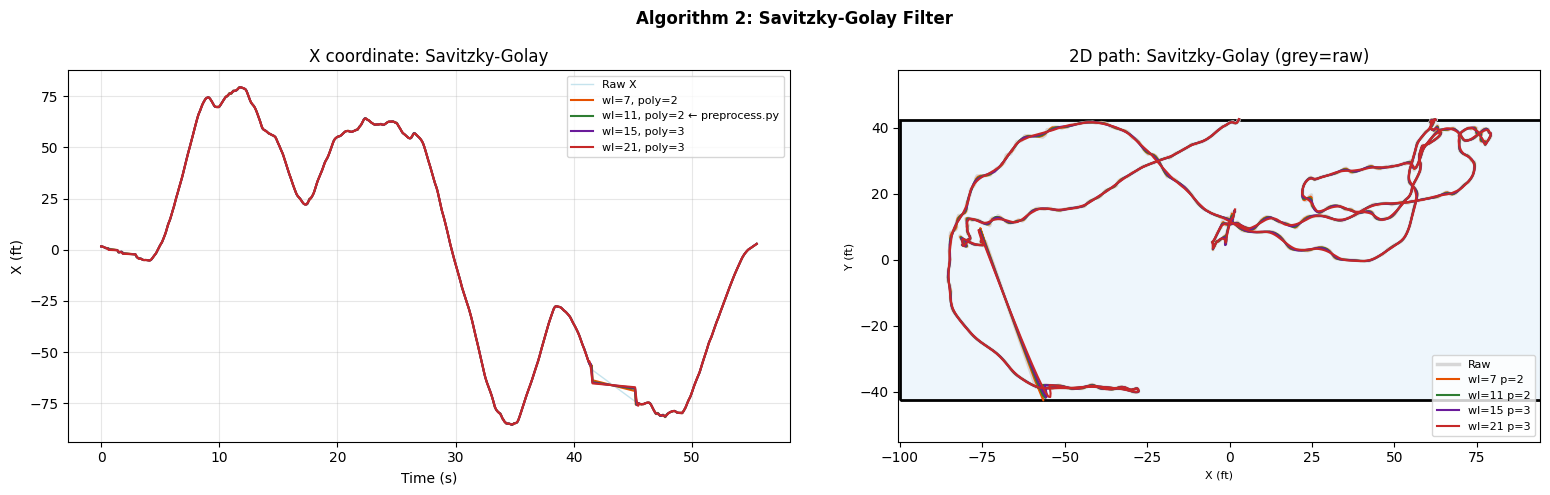

In [6]:
SAVGOL_PARAMS = [
    (7,  2),   # short window, quadratic
    (11, 2),   # medium window, quadratic  ← used by preprocess.py
    (15, 3),   # medium-long, cubic
    (21, 3),   # long, cubic
]
savgol_results = {(wl, po): (savgol_filter(rx, wl, po), savgol_filter(ry, wl, po))
                  for wl, po in SAVGOL_PARAMS}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_sg = ['#E65100', '#2E7D32', '#6A1B9A', '#C62828']

axes[0].plot(t, rx, color='lightblue', lw=1, alpha=0.7, label='Raw X')
for ((wl, po), (sx, sy)), col in zip(savgol_results.items(), colors_sg):
    lbl = f'wl={wl}, poly={po}' + (' ← preprocess.py' if (wl, po) == (11, 2) else '')
    axes[0].plot(t, sx, lw=1.5, color=col, label=lbl)
axes[0].set_title('X coordinate: Savitzky-Golay'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('X (ft)')

draw_rink_mini(axes[1], xlim=xlim, ylim=ylim)
axes[1].plot(rx, ry, color='lightgrey', lw=2.5, alpha=0.9, label='Raw', zorder=3)
for ((wl, po), (sx, sy)), col in zip(savgol_results.items(), colors_sg):
    axes[1].plot(sx, sy, color=col, lw=1.5, label=f'wl={wl} p={po}', zorder=5)
axes[1].legend(fontsize=8); axes[1].set_title('2D path: Savitzky-Golay (grey=raw)')

plt.suptitle('Algorithm 2: Savitzky-Golay Filter', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

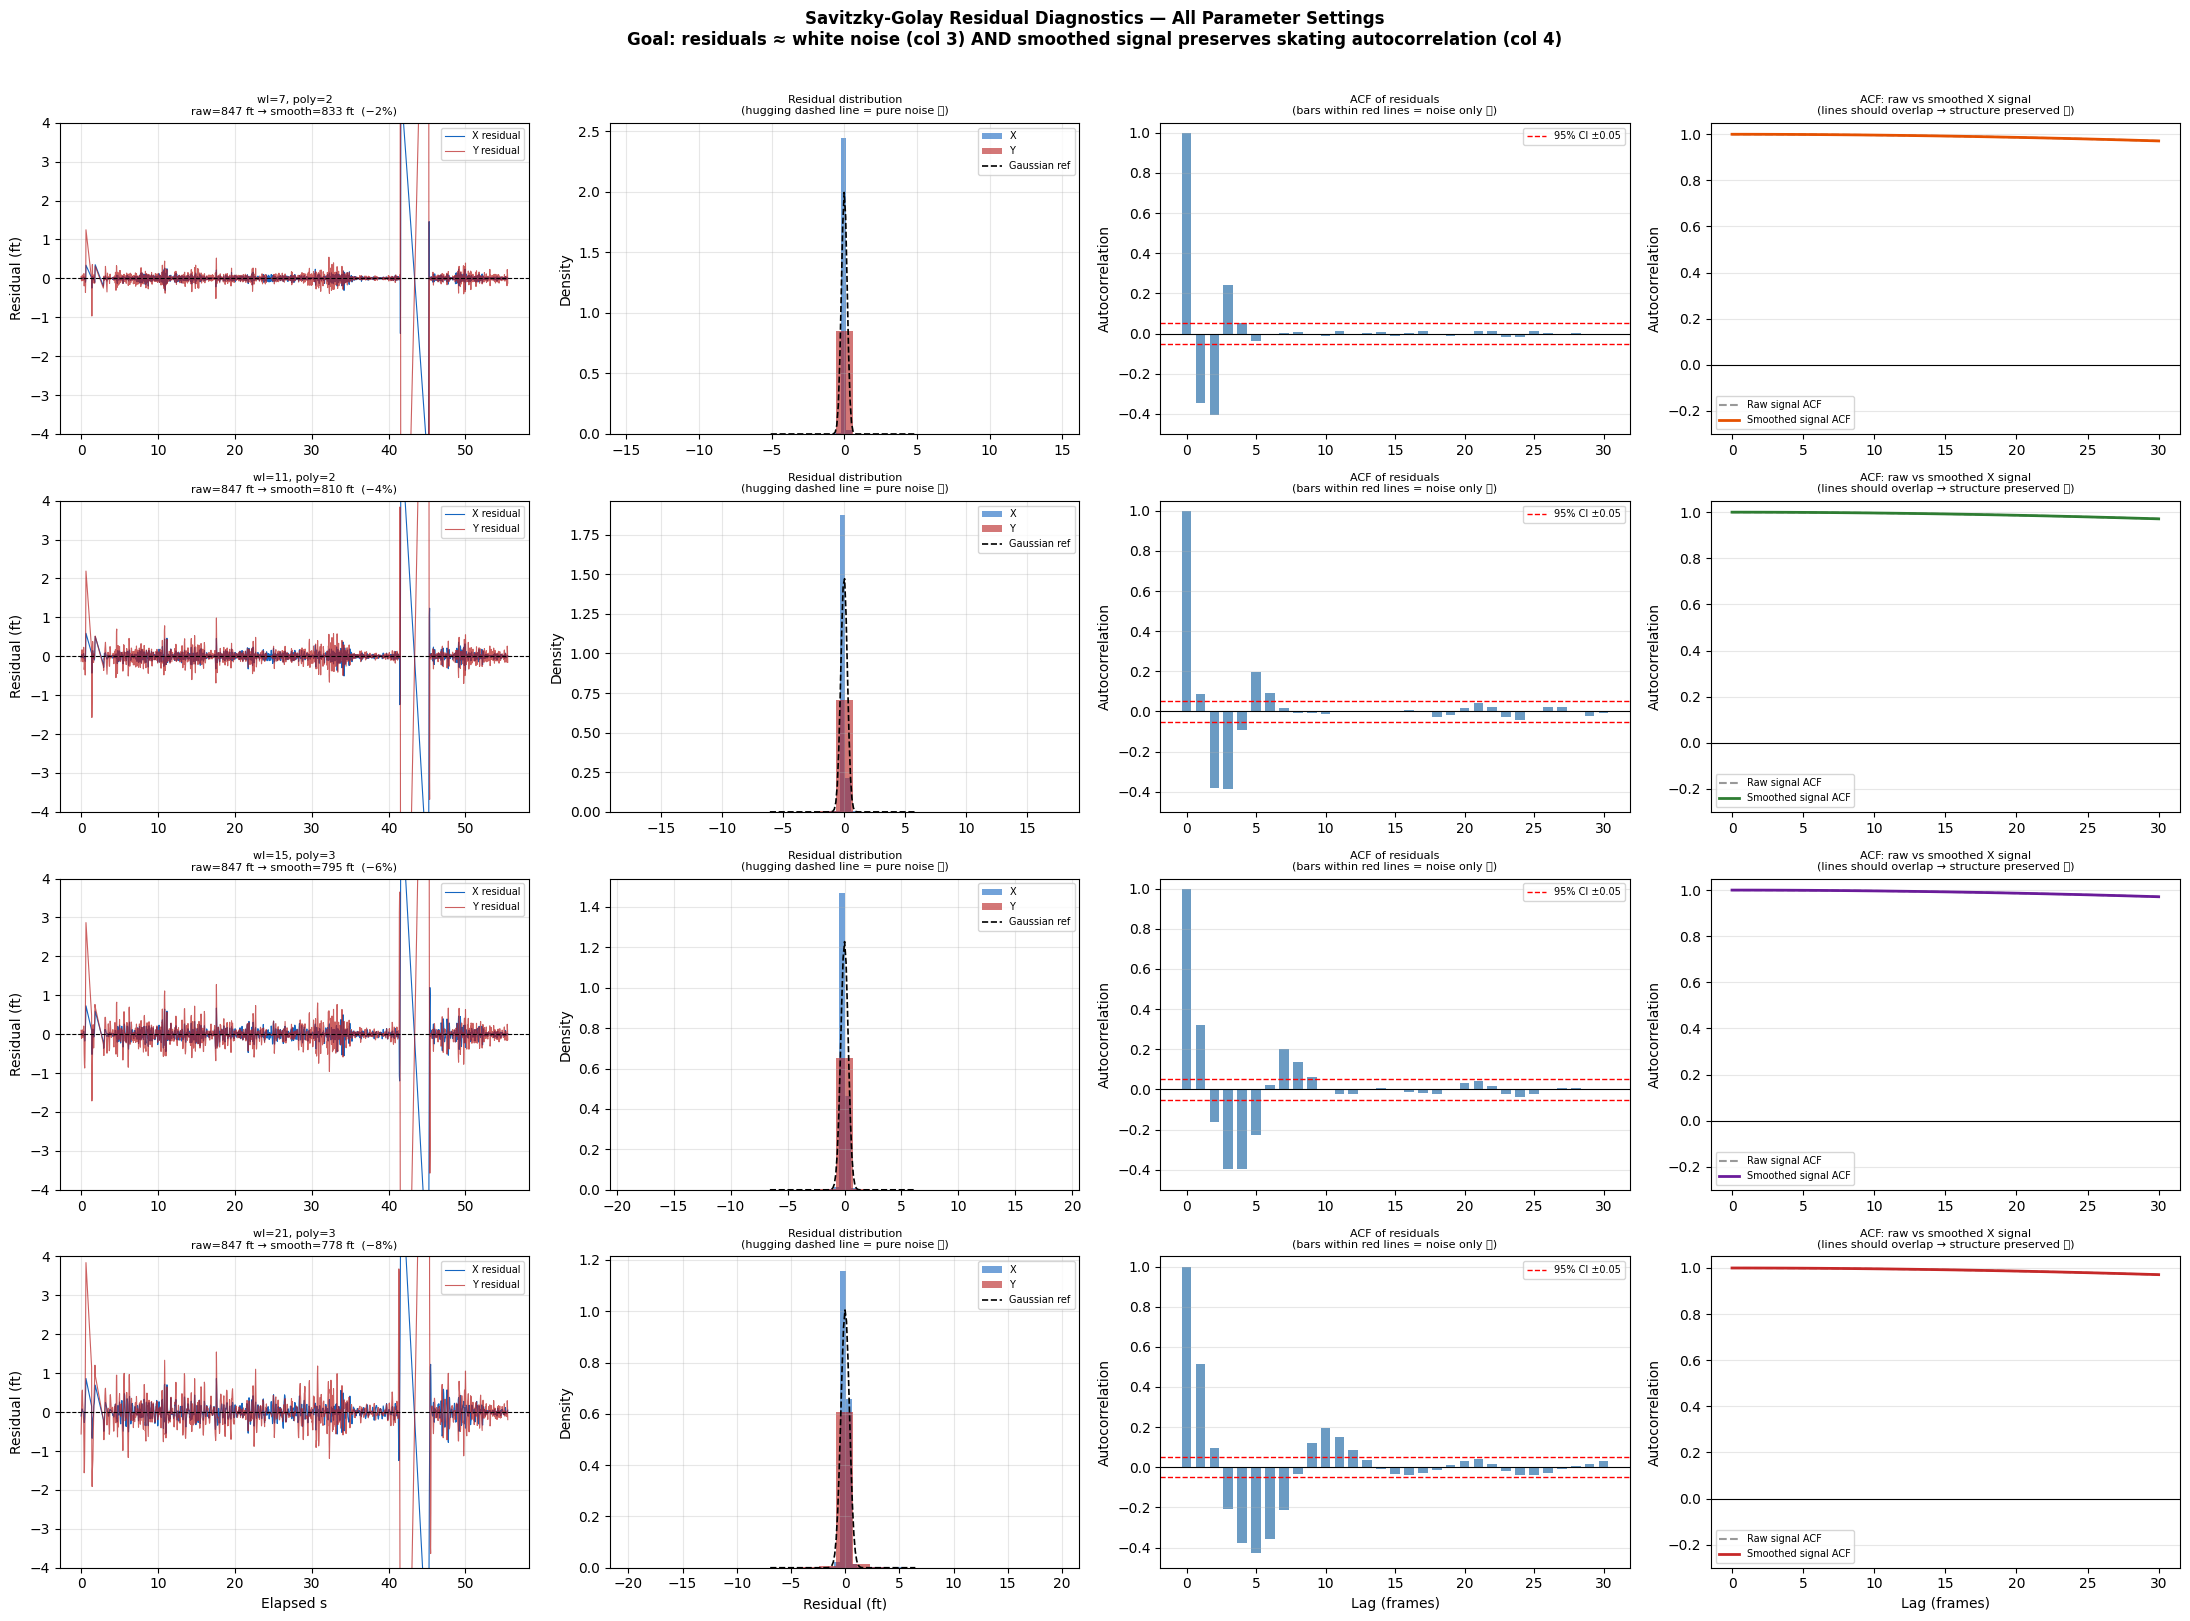

In [7]:
raw_pl = np.sum(np.sqrt(np.diff(rx)**2 + np.diff(ry)**2))

def autocorr(x, max_lag=30):
    x = x - x.mean()
    c0 = np.dot(x, x)
    return np.array([np.dot(x[:len(x)-k], x[k:]) / c0 for k in range(max_lag + 1)])

conf = 1.96 / np.sqrt(len(rx))
lags = np.arange(31)

# ACF of the raw signal — skating motion has high natural autocorrelation
# A good smoother should PRESERVE this structure while removing high-frequency noise
raw_acf_x = autocorr(rx)

fig, axes = plt.subplots(len(savgol_results), 4, figsize=(22, 4 * len(savgol_results)))
colors_sg = ['#E65100', '#2E7D32', '#6A1B9A', '#C62828']

for row, ((wl, po), (sx, sy)) in enumerate(savgol_results.items()):
    res_x = rx - sx
    res_y = ry - sy
    sg_pl  = np.sum(np.sqrt(np.diff(sx)**2 + np.diff(sy)**2))
    res_acf = autocorr(res_x)
    sig_acf = autocorr(sx)       # ACF of the smoothed signal itself

    col = colors_sg[row]
    ax0, ax1, ax2, ax3 = axes[row]

    # --- 1. Residuals over time ---
    ax0.plot(t, res_x, color='#1565C0', lw=0.8, label='X residual')
    ax0.plot(t, res_y, color='#B71C1C', lw=0.8, label='Y residual', alpha=0.7)
    ax0.axhline(0, color='black', lw=0.8, linestyle='--')
    ax0.set_ylim(-4, 4)
    ax0.set_ylabel('Residual (ft)')
    ax0.grid(alpha=0.3)
    ax0.legend(fontsize=7)
    pct_removed = 100 * (raw_pl - sg_pl) / raw_pl
    ax0.set_title(f'wl={wl}, poly={po}\n'
                  f'raw={raw_pl:.0f} ft → smooth={sg_pl:.0f} ft  (−{pct_removed:.0f}%)', fontsize=8)
    if row == len(savgol_results) - 1:
        ax0.set_xlabel('Elapsed s')

    # --- 2. Residual distribution ---
    ax1.hist(res_x, bins=25, color='#1565C0', alpha=0.6, label='X', density=True)
    ax1.hist(res_y, bins=25, color='#B71C1C', alpha=0.6, label='Y', density=True)
    # overlay a reference Gaussian
    mu, sd = res_x.mean(), res_x.std()
    xs = np.linspace(res_x.min(), res_x.max(), 100)
    ax1.plot(xs, np.exp(-0.5*((xs-mu)/sd)**2) / (sd*np.sqrt(2*np.pi)),
             'k--', lw=1.2, label='Gaussian ref')
    ax1.set_ylabel('Density')
    ax1.set_title('Residual distribution\n(hugging dashed line = pure noise ✅)', fontsize=8)
    ax1.legend(fontsize=7)
    ax1.grid(alpha=0.3)
    if row == len(savgol_results) - 1:
        ax1.set_xlabel('Residual (ft)')

    # --- 3. ACF of residuals — should be white noise ---
    ax2.bar(lags, res_acf, color='steelblue', alpha=0.8, width=0.7)
    ax2.axhline( conf, color='red', linestyle='--', lw=1, label=f'95% CI ±{conf:.2f}')
    ax2.axhline(-conf, color='red', linestyle='--', lw=1)
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_ylim(-0.5, 1.05)
    ax2.set_ylabel('Autocorrelation')
    ax2.set_title('ACF of residuals\n(bars within red lines = noise only ✅)', fontsize=8)
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3, axis='y')
    if row == len(savgol_results) - 1:
        ax2.set_xlabel('Lag (frames)')

    # --- 4. ACF of smoothed signal vs raw — preserved skating structure ---
    ax3.plot(lags, raw_acf_x, color='#999999', lw=1.5, linestyle='--', label='Raw signal ACF', zorder=3)
    ax3.plot(lags, sig_acf,   color=col,       lw=2,   label='Smoothed signal ACF', zorder=4)
    ax3.axhline(0, color='black', lw=0.8)
    ax3.set_ylim(-0.3, 1.05)
    ax3.set_ylabel('Autocorrelation')
    ax3.set_title('ACF: raw vs smoothed X signal\n(lines should overlap → structure preserved ✅)', fontsize=8)
    ax3.legend(fontsize=7)
    ax3.grid(alpha=0.3, axis='y')
    if row == len(savgol_results) - 1:
        ax3.set_xlabel('Lag (frames)')

plt.suptitle(
    'Savitzky-Golay Residual Diagnostics — All Parameter Settings\n'
    'Goal: residuals ≈ white noise (col 3) AND smoothed signal preserves skating autocorrelation (col 4)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## Algorithm 3: Kalman Filter

The gold standard for tracking data. Models the player as a **physical system** with position and velocity state, and optimally combines:
- **Prediction**: where should the player be based on physics (constant-velocity model)?
- **Measurement update**: what did the sensor actually observe?

Key parameters:
- `Q` (process noise): how much can velocity change between frames? Higher = allows more acceleration = follows data more
- `R` (measurement noise): how noisy is the sensor? Higher = trust physics more = smoother path

We use state `[x, vx, y, vy]` — which also gives us clean velocity estimates for free.

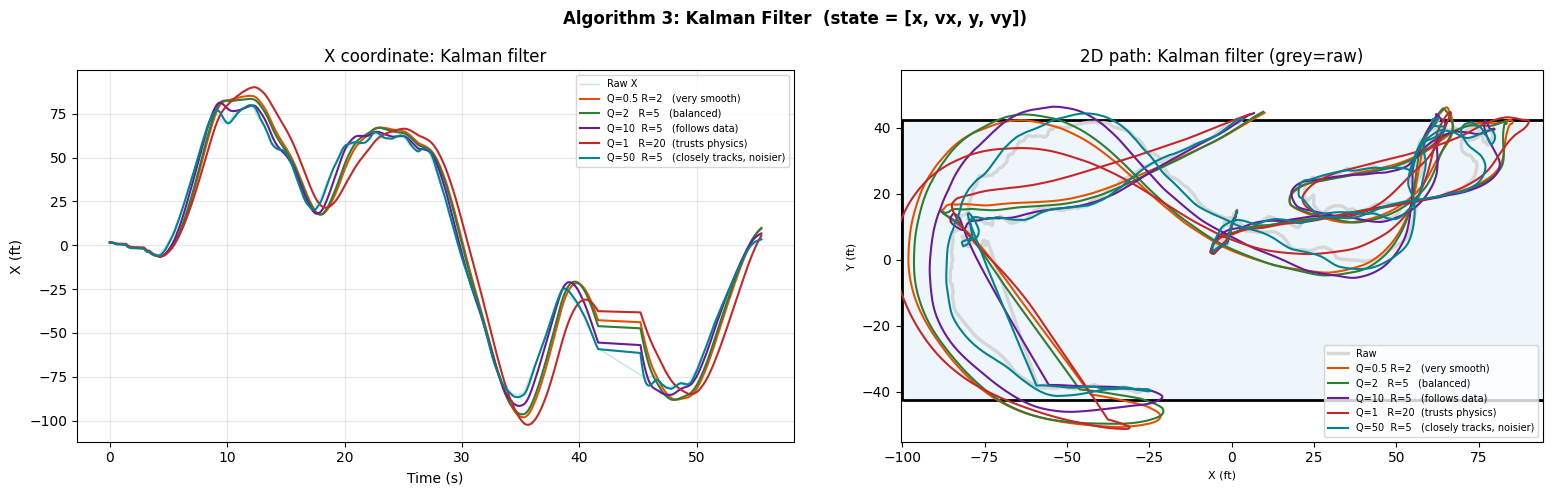

In [8]:
def kalman_2d(x_obs, y_obs, dt=1/30, process_noise=1.0, measurement_noise=5.0):
    """
    2D Kalman filter using filterpy: state = [x, vx, y, vy]
    Returns (smoothed_x, smoothed_y).
    """
    kf = KalmanFilter(dim_x=4, dim_z=2)
    kf.F = np.array([[1, dt, 0,  0],
                     [0,  1, 0,  0],
                     [0,  0, 1, dt],
                     [0,  0, 0,  1]])
    kf.H = np.array([[1, 0, 0, 0],
                     [0, 0, 1, 0]])
    kf.Q = process_noise * np.diag([dt**4/4, dt**2, dt**4/4, dt**2])
    kf.R = measurement_noise * np.eye(2)
    kf.x = np.array([[x_obs[0]], [0.0], [y_obs[0]], [0.0]])
    kf.P = np.eye(4) * 10.0

    sx, sy = np.zeros(len(x_obs)), np.zeros(len(x_obs))
    sx[0], sy[0] = x_obs[0], y_obs[0]
    for k in range(1, len(x_obs)):
        kf.predict()
        kf.update(np.array([[x_obs[k]], [y_obs[k]]]))
        sx[k] = kf.x[0, 0]
        sy[k] = kf.x[2, 0]
    return sx, sy

KALMAN_PARAMS = [
    (0.5,  2.0,  'Q=0.5 R=2   (very smooth)'),
    (2.0,  5.0,  'Q=2   R=5   (balanced)'),
    (10.0, 5.0,  'Q=10  R=5   (follows data)'),
    (1.0,  20.0, 'Q=1   R=20  (trusts physics)'),
    (50.0, 1.0,  'Q=50  R=5   (closely tracks, noisier)'),
]
kalman_results = {lbl: kalman_2d(rx, ry, dt=dt_med, process_noise=q, measurement_noise=r)
                  for q, r, lbl in KALMAN_PARAMS}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_k = ['#E65100', '#2E7D32', '#6A1B9A', '#C62828', '#00838F']

axes[0].plot(t, rx, color='lightblue', lw=1, alpha=0.7, label='Raw X')
for (lbl, (sx, sy)), col in zip(kalman_results.items(), colors_k):
    axes[0].plot(t, sx, lw=1.5, color=col, label=lbl)
axes[0].set_title('X coordinate: Kalman filter'); axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('X (ft)')

draw_rink_mini(axes[1], xlim=xlim, ylim=ylim)
axes[1].plot(rx, ry, color='lightgrey', lw=2.5, alpha=0.9, label='Raw', zorder=3)
for (lbl, (sx, sy)), col in zip(kalman_results.items(), colors_k):
    axes[1].plot(sx, sy, color=col, lw=1.5, label=lbl, zorder=5)
axes[1].legend(fontsize=7); axes[1].set_title('2D path: Kalman filter (grey=raw)')

plt.suptitle('Algorithm 3: Kalman Filter  (state = [x, vx, y, vy])', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### Interpreting Path Length Difference

The raw path length is **inflated by noise jitter** — every small sensor wobble adds distance that isn't real skating. So the Kalman path being shorter isn't necessarily bad; some of that gap is noise that was correctly removed.

The key diagnostic is the **residuals** (raw position − smoothed position):
- If residuals look like **white noise** (small, random, no pattern) → the filter is cleanly separating real signal from sensor noise ✅
- If residuals show **systematic structure** (bumps, trends, autocorrelation) → the filter is eating real skating motion, not just noise ⚠️

We can also look at the **autocorrelation of residuals** — white noise has zero autocorrelation at all lags > 0.

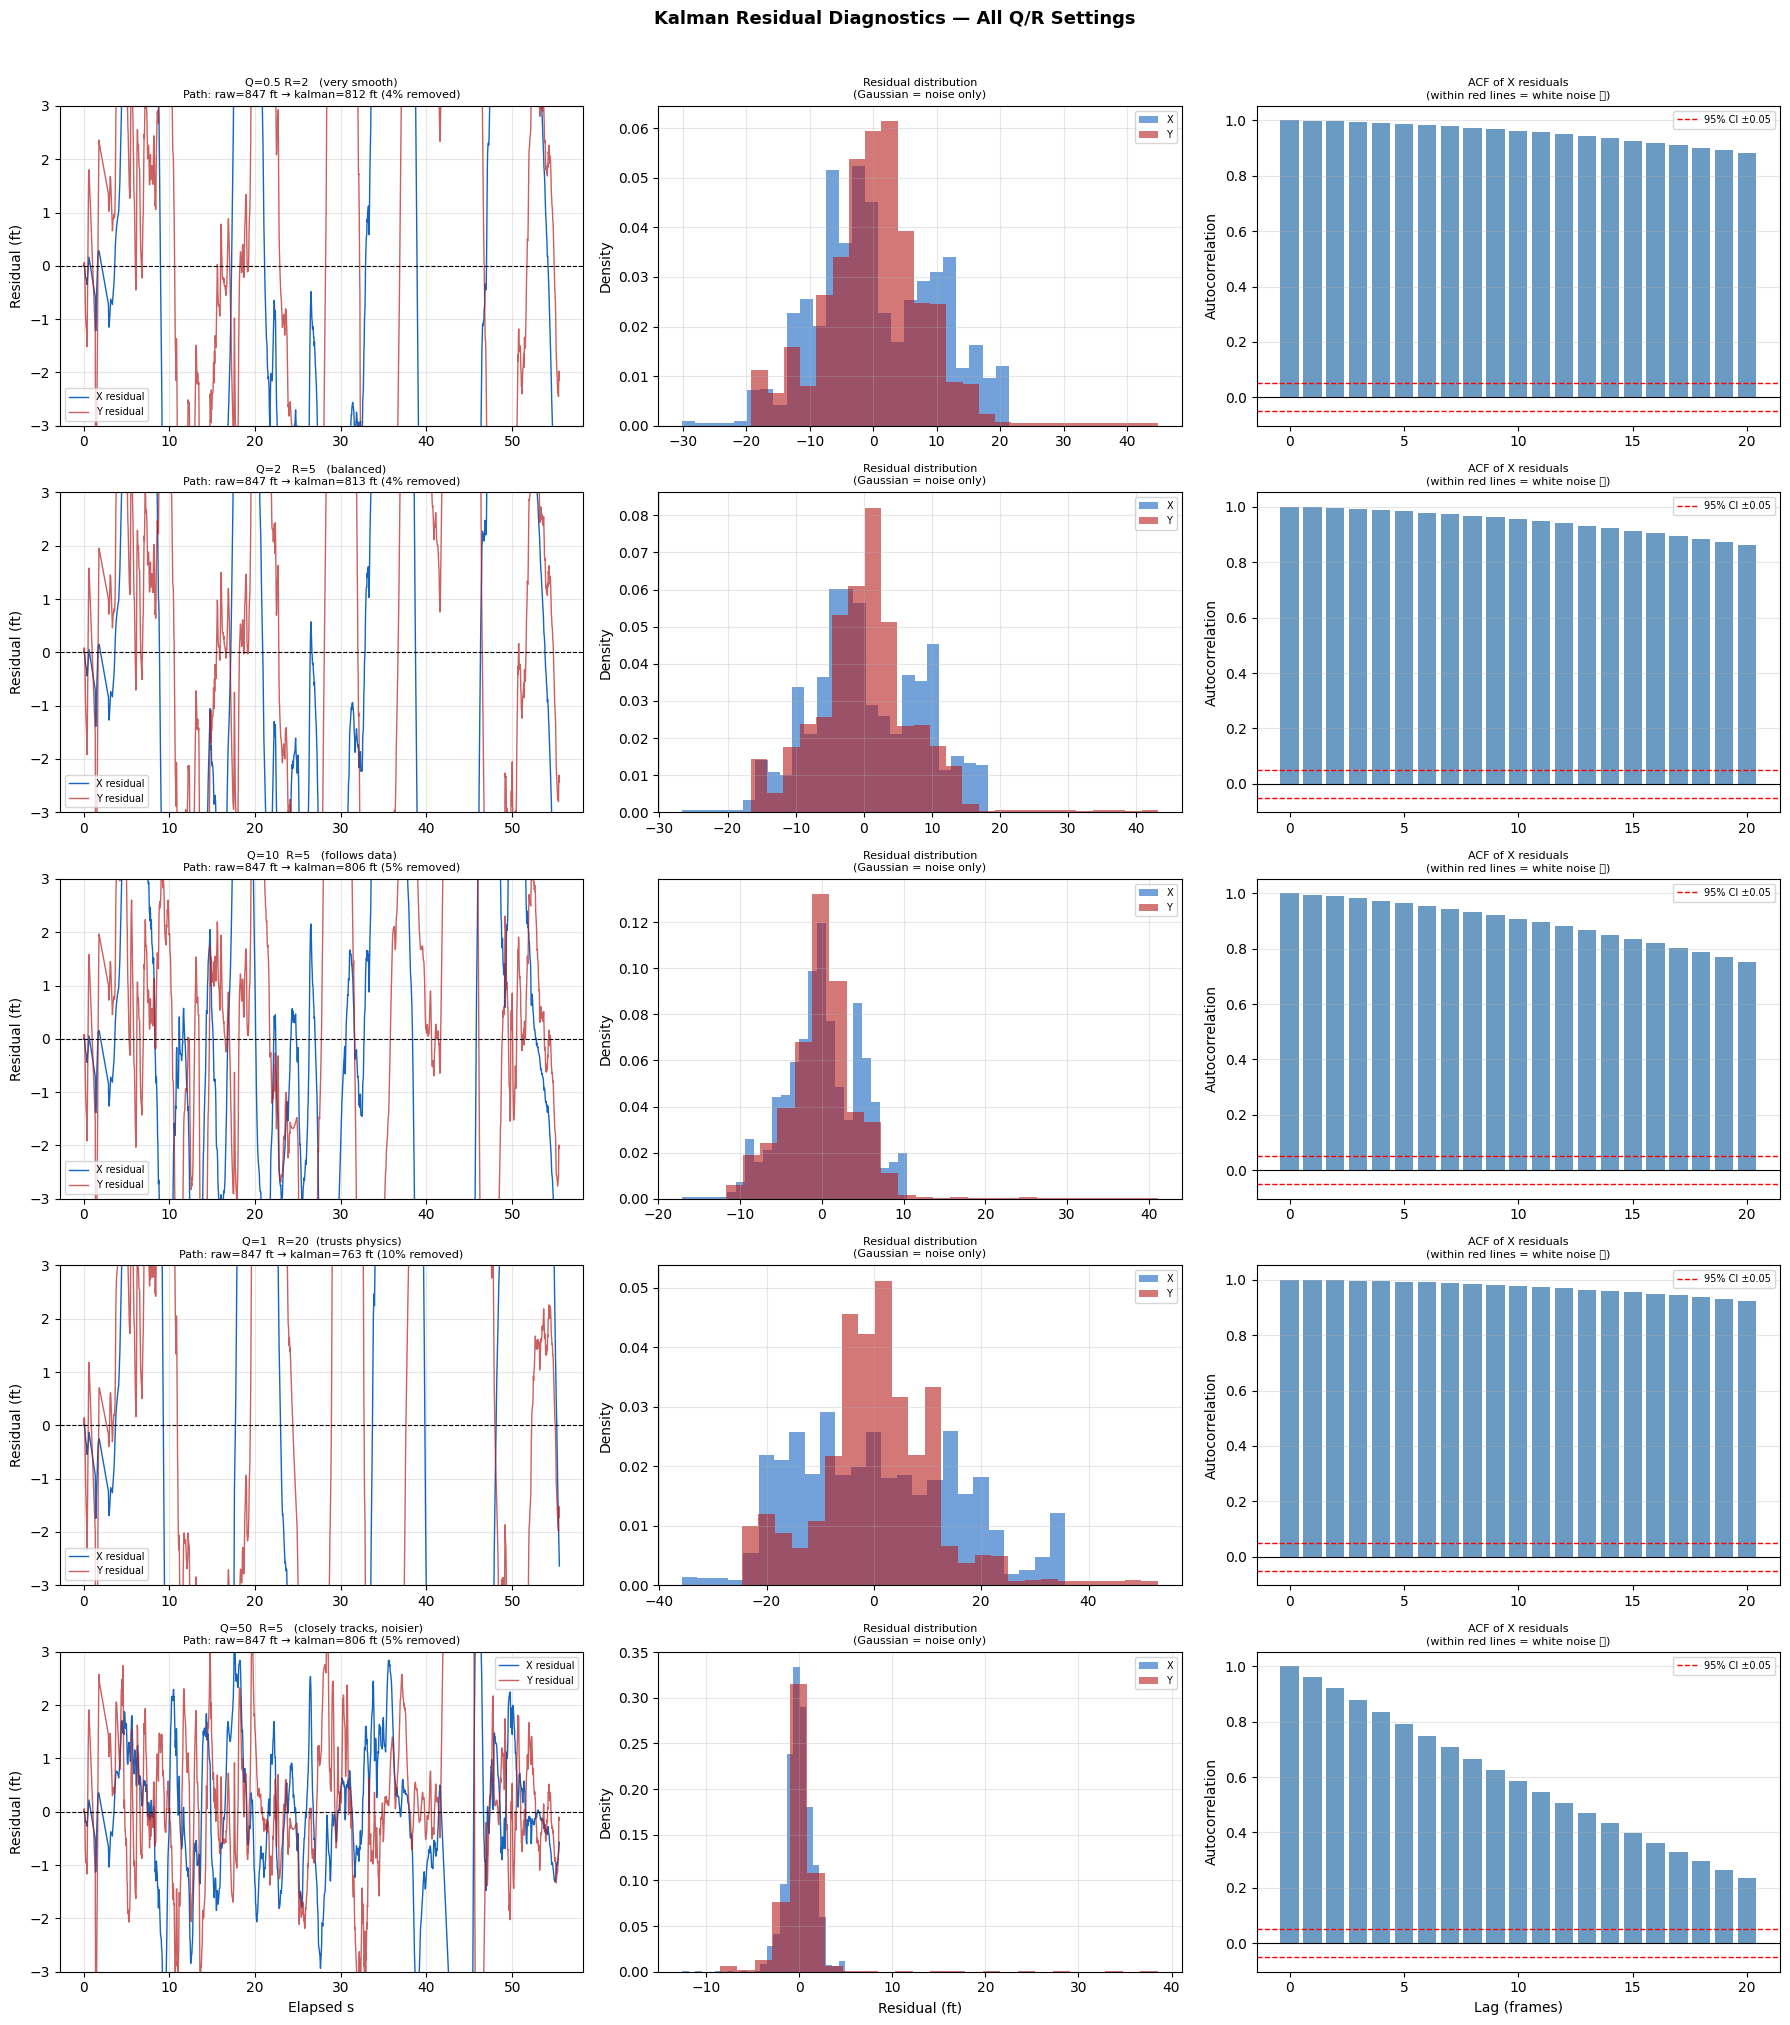

In [9]:
raw_pl = np.sum(np.sqrt(np.diff(rx)**2 + np.diff(ry)**2))

def autocorr(x, max_lag=20):
    x = x - x.mean()
    c0 = np.dot(x, x)
    return [np.dot(x[:len(x)-k], x[k:]) / c0 for k in range(max_lag+1)]

conf = 1.96 / np.sqrt(len(rx))
lags = list(range(21))

fig, axes = plt.subplots(len(kalman_results), 3, figsize=(18, 4 * len(kalman_results)))

for row, (lbl, (kx, ky)) in enumerate(kalman_results.items()):
    res_x = rx - kx
    res_y = ry - ky
    kalm_pl = np.sum(np.sqrt(np.diff(kx)**2 + np.diff(ky)**2))
    ac = autocorr(res_x)

    ax0, ax1, ax2 = axes[row]

    # 1. Residuals over time
    ax0.plot(t, res_x, color='#1565C0', lw=1, label='X residual')
    ax0.plot(t, res_y, color='#B71C1C', lw=1, label='Y residual', alpha=0.7)
    ax0.axhline(0, color='black', lw=0.8, linestyle='--')
    ax0.set_ylabel('Residual (ft)')
    ax0.set_ylim(-3, 3)
    ax0.grid(alpha=0.3)
    ax0.legend(fontsize=7)
    ax0.set_title(f'{lbl}\nPath: raw={raw_pl:.0f} ft → kalman={kalm_pl:.0f} ft '
                  f'({100*(raw_pl-kalm_pl)/raw_pl:.0f}% removed)', fontsize=8)
    if row == len(kalman_results) - 1:
        ax0.set_xlabel('Elapsed s')

    # 2. Residual distribution
    ax1.hist(res_x, bins=25, color='#1565C0', alpha=0.6, label='X', density=True)
    ax1.hist(res_y, bins=25, color='#B71C1C', alpha=0.6, label='Y', density=True)
    ax1.set_ylabel('Density')
    ax1.grid(alpha=0.3)
    ax1.legend(fontsize=7)
    ax1.set_title('Residual distribution\n(Gaussian = noise only)', fontsize=8)
    if row == len(kalman_results) - 1:
        ax1.set_xlabel('Residual (ft)')

    # 3. Autocorrelation
    ax2.bar(lags, ac, color='steelblue', alpha=0.8)
    ax2.axhline(conf,  color='red', linestyle='--', lw=1, label=f'95% CI ±{conf:.2f}')
    ax2.axhline(-conf, color='red', linestyle='--', lw=1)
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_ylabel('Autocorrelation')
    ax2.grid(alpha=0.3, axis='y')
    ax2.legend(fontsize=7)
    ax2.set_title('ACF of X residuals\n(within red lines = white noise ✅)', fontsize=8)
    if row == len(kalman_results) - 1:
        ax2.set_xlabel('Lag (frames)')

plt.suptitle('Kalman Residual Diagnostics — All Q/R Settings', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Algorithm 4: Gaussian Kernel Smoothing

Convolves the signal with a Gaussian bell curve. Similar to a weighted moving average but with a softer roll-off at the edges. Applied symmetrically so there's no lag.

- `sigma` controls width in frames: higher = wider kernel = smoother
- At 30 Hz: σ=1 ≈ 33 ms, σ=3 ≈ 100 ms, σ=10 ≈ 333 ms
- Edge effects: the filter wraps or reflects at boundaries (controlled by `mode` param)

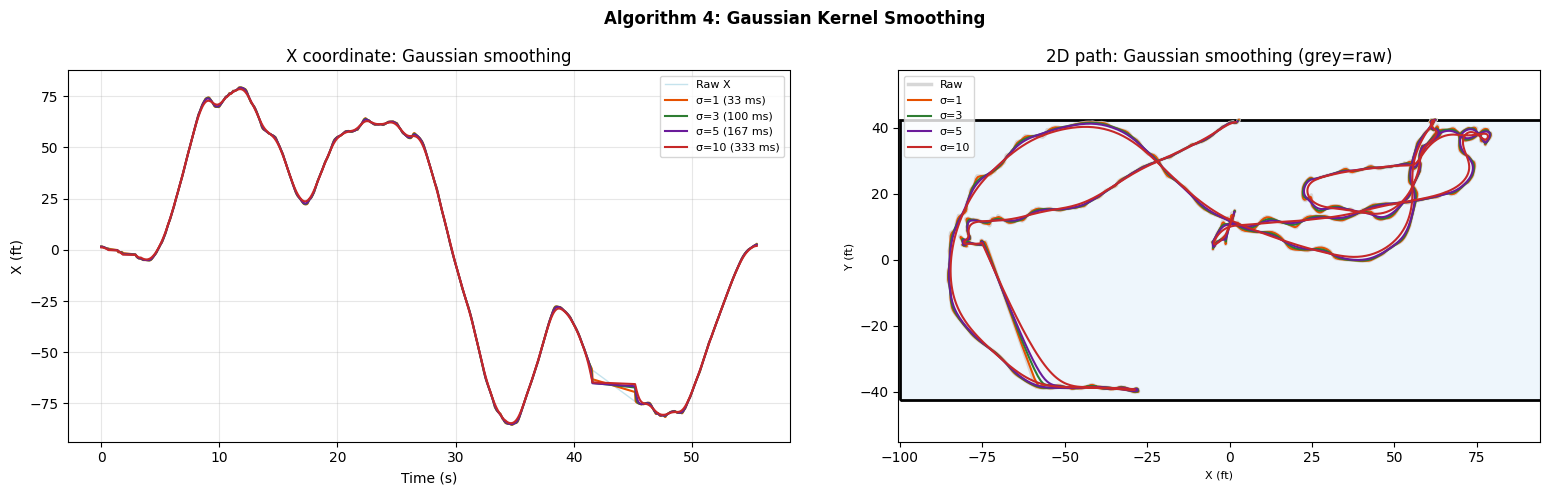

In [10]:
SIGMAS = [1, 3, 5, 10]
gauss_results = {s: (gaussian_filter1d(rx, sigma=s), gaussian_filter1d(ry, sigma=s)) for s in SIGMAS}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_g = ['#E65100', '#2E7D32', '#6A1B9A', '#C62828']

axes[0].plot(t, rx, color='lightblue', lw=1, alpha=0.7, label='Raw X')
for (sigma, (sx, sy)), col in zip(gauss_results.items(), colors_g):
    axes[0].plot(t, sx, lw=1.5, color=col, label=f'σ={sigma} ({sigma/30*1000:.0f} ms)')
axes[0].set_title('X coordinate: Gaussian smoothing'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('X (ft)')

draw_rink_mini(axes[1], xlim=xlim, ylim=ylim)
axes[1].plot(rx, ry, color='lightgrey', lw=2.5, alpha=0.9, label='Raw', zorder=3)
for (sigma, (sx, sy)), col in zip(gauss_results.items(), colors_g):
    axes[1].plot(sx, sy, color=col, lw=1.5, label=f'σ={sigma}', zorder=5)
axes[1].legend(fontsize=8); axes[1].set_title('2D path: Gaussian smoothing (grey=raw)')

plt.suptitle('Algorithm 4: Gaussian Kernel Smoothing', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Side-by-Side Comparison

One representative setting per algorithm on the same plot. The rink panel shows 2D paths; the time-series panels show where each method diverges from the raw signal.

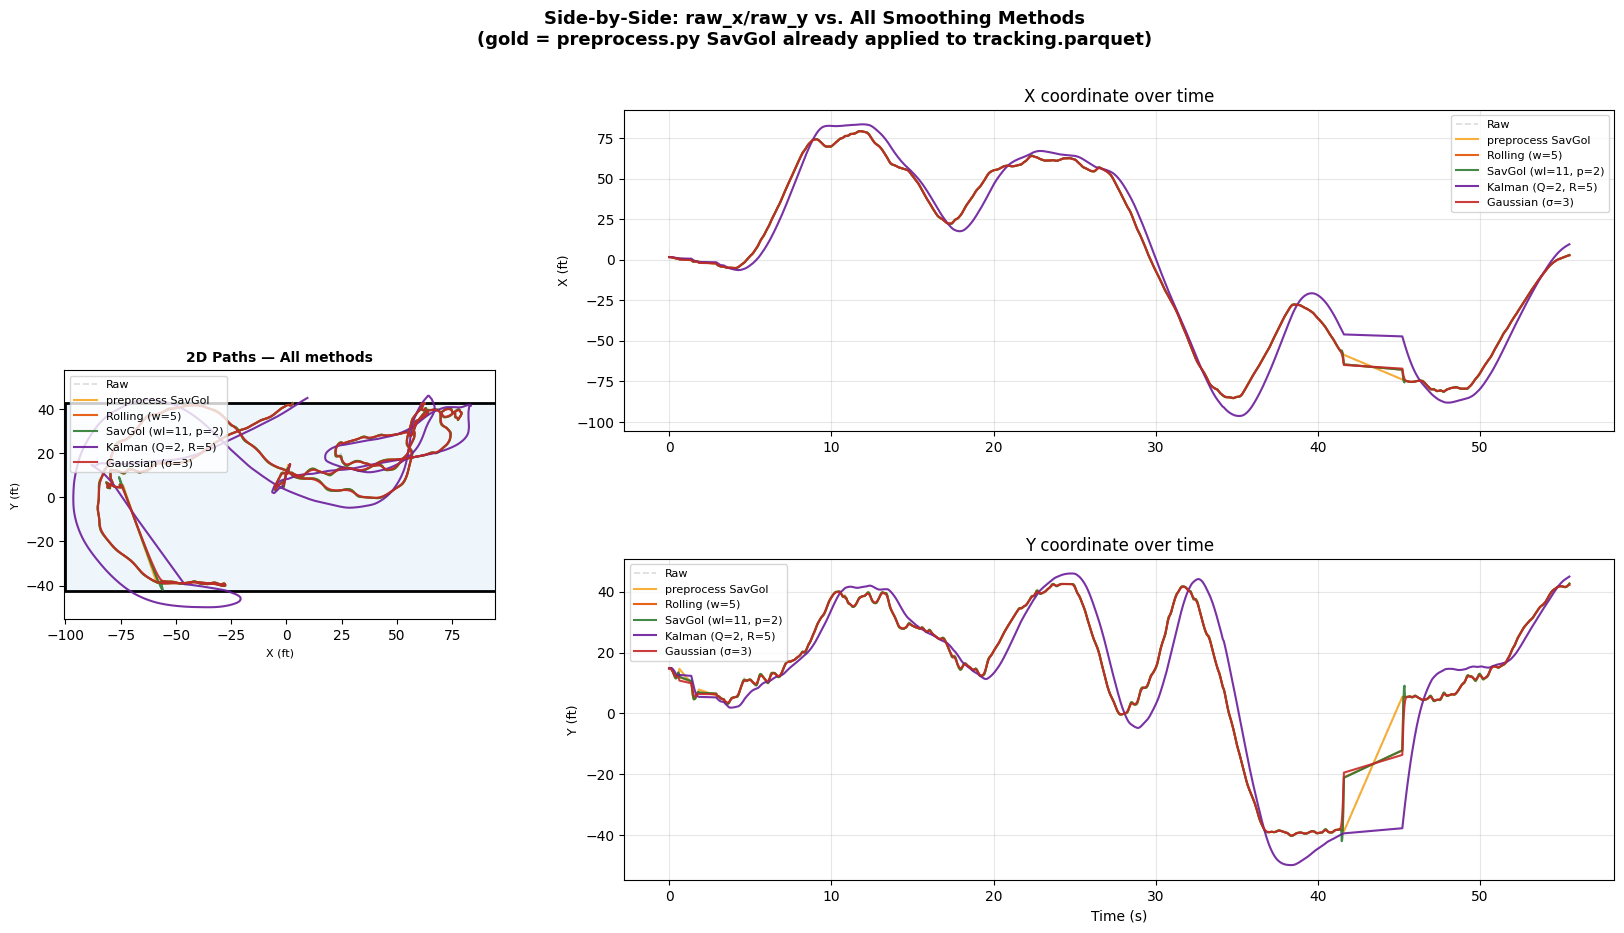

In [11]:
representative = {
    'Raw':                     (rx.copy(),        ry.copy()),
    'preprocess SavGol':       (sx_savgol_pp,     sy_savgol_pp),   # wl=11, p=2 baked in by preprocess.py
    'Rolling (w=5)':           rolling_results[5],
    'SavGol (wl=11, p=2)':     savgol_results[(11, 2)],
    'Kalman (Q=2, R=5)':       kalman_results['Q=2   R=5   (balanced)'],
    'Gaussian (σ=3)':          gauss_results[3],
}
method_colors = {
    'Raw':                     '#999999',
    'preprocess SavGol':       '#F9A825',
    'Rolling (w=5)':           '#E65100',
    'SavGol (wl=11, p=2)':     '#2E7D32',
    'Kalman (Q=2, R=5)':       '#6A1B9A',
    'Gaussian (σ=3)':          '#C62828',
}

fig = plt.figure(figsize=(20, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)
ax_rink = fig.add_subplot(gs[:, 0])
ax_x    = fig.add_subplot(gs[0, 1:])
ax_y    = fig.add_subplot(gs[1, 1:])

draw_rink_mini(ax_rink, xlim=xlim, ylim=ylim)
ax_rink.set_title('2D Paths — All methods', fontsize=10, fontweight='bold')

for method, (sx, sy) in representative.items():
    col = method_colors[method]
    lw  = 1.5  if method != 'Raw' else 1.2
    al  = 0.9  if method != 'Raw' else 0.35
    ls  = '--'  if method == 'Raw' else '-'
    zo  = 3    if method == 'Raw' else 5
    ax_rink.plot(sx, sy, color=col, lw=lw, alpha=al, label=method, zorder=zo, linestyle=ls)
    ax_x.plot(t, sx, color=col, lw=lw, alpha=al, label=method, linestyle=ls)
    ax_y.plot(t, sy, color=col, lw=lw, alpha=al, label=method, linestyle=ls)

ax_rink.legend(fontsize=8, loc='upper left')
ax_x.set_ylabel('X (ft)', fontsize=9); ax_x.set_title('X coordinate over time')
ax_x.legend(fontsize=8); ax_x.grid(alpha=0.3)
ax_y.set_xlabel('Time (s)'); ax_y.set_ylabel('Y (ft)', fontsize=9)
ax_y.set_title('Y coordinate over time'); ax_y.legend(fontsize=8); ax_y.grid(alpha=0.3)

plt.suptitle('Side-by-Side: raw_x/raw_y vs. All Smoothing Methods\n'
             '(gold = preprocess.py SavGol already applied to tracking.parquet)',
             fontsize=13, fontweight='bold')
plt.show()

## Quantitative Evaluation

Three metrics across all parameter settings:

| Metric | What it tells us |
|---|---|
| **Path length (% of raw)** | < 100% means over-smoothing shortened the path; much less = distorted |
| **Speed variance (% of raw)** | Good smoothing cuts noise variance while preserving real variation |
| **MSE from raw (ft²)** | Higher = more aggressive smoothing / farther from raw positions |

In [12]:
def path_length(sx, sy):
    return np.sum(np.sqrt(np.diff(sx)**2 + np.diff(sy)**2))

def speed_variance(sx, sy, dt=1/30):
    speeds = np.sqrt(np.diff(sx)**2 + np.diff(sy)**2) / dt
    return speeds.var()

def mse_from_raw(sx, sy):
    return np.mean((sx - rx)**2 + (sy - ry)**2)

all_methods = {
    'Raw':                    (rx, ry),
    'preprocess SavGol':      (sx_savgol_pp, sy_savgol_pp),
    'Rolling w=3':            rolling_results[3],
    'Rolling w=5':            rolling_results[5],
    'Rolling w=10':           rolling_results[10],
    'SavGol wl=7  p=2':       savgol_results[(7,  2)],
    'SavGol wl=11 p=2':       savgol_results[(11, 2)],
    'SavGol wl=15 p=3':       savgol_results[(15, 3)],
    'SavGol wl=21 p=3':       savgol_results[(21, 3)],
    **{lbl: v for lbl, v in kalman_results.items()},
    'Gaussian σ=1':           gauss_results[1],
    'Gaussian σ=3':           gauss_results[3],
    'Gaussian σ=5':           gauss_results[5],
    'Gaussian σ=10':          gauss_results[10],
}

raw_pl = path_length(rx, ry)
raw_sv = speed_variance(rx, ry, dt=dt_med)
rows = []
for name, (sx, sy) in all_methods.items():
    rows.append({
        'Method': name,
        'Path Length (ft)': round(path_length(sx, sy), 1),
        '% of Raw Length': round(100 * path_length(sx, sy) / raw_pl, 1),
        'Speed Var % of Raw': round(100 * speed_variance(sx, sy, dt=dt_med) / raw_sv, 1),
        'MSE from Raw (ft²)': round(mse_from_raw(sx, sy), 3),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

                               Method  Path Length (ft)  % of Raw Length  Speed Var % of Raw  MSE from Raw (ft²)
                                  Raw             846.6            100.0               100.0               0.000
                    preprocess SavGol             800.9             94.6                99.6               0.033
                          Rolling w=3             811.2             95.8                34.9               0.333
                          Rolling w=5             789.0             93.2                21.6               0.619
                         Rolling w=10             755.9             89.3                11.8               1.461
                     SavGol wl=7  p=2             833.1             98.4                34.1               0.368
                     SavGol wl=11 p=2             809.9             95.7                21.7               0.651
                     SavGol wl=15 p=3             794.9             93.9                16.0    

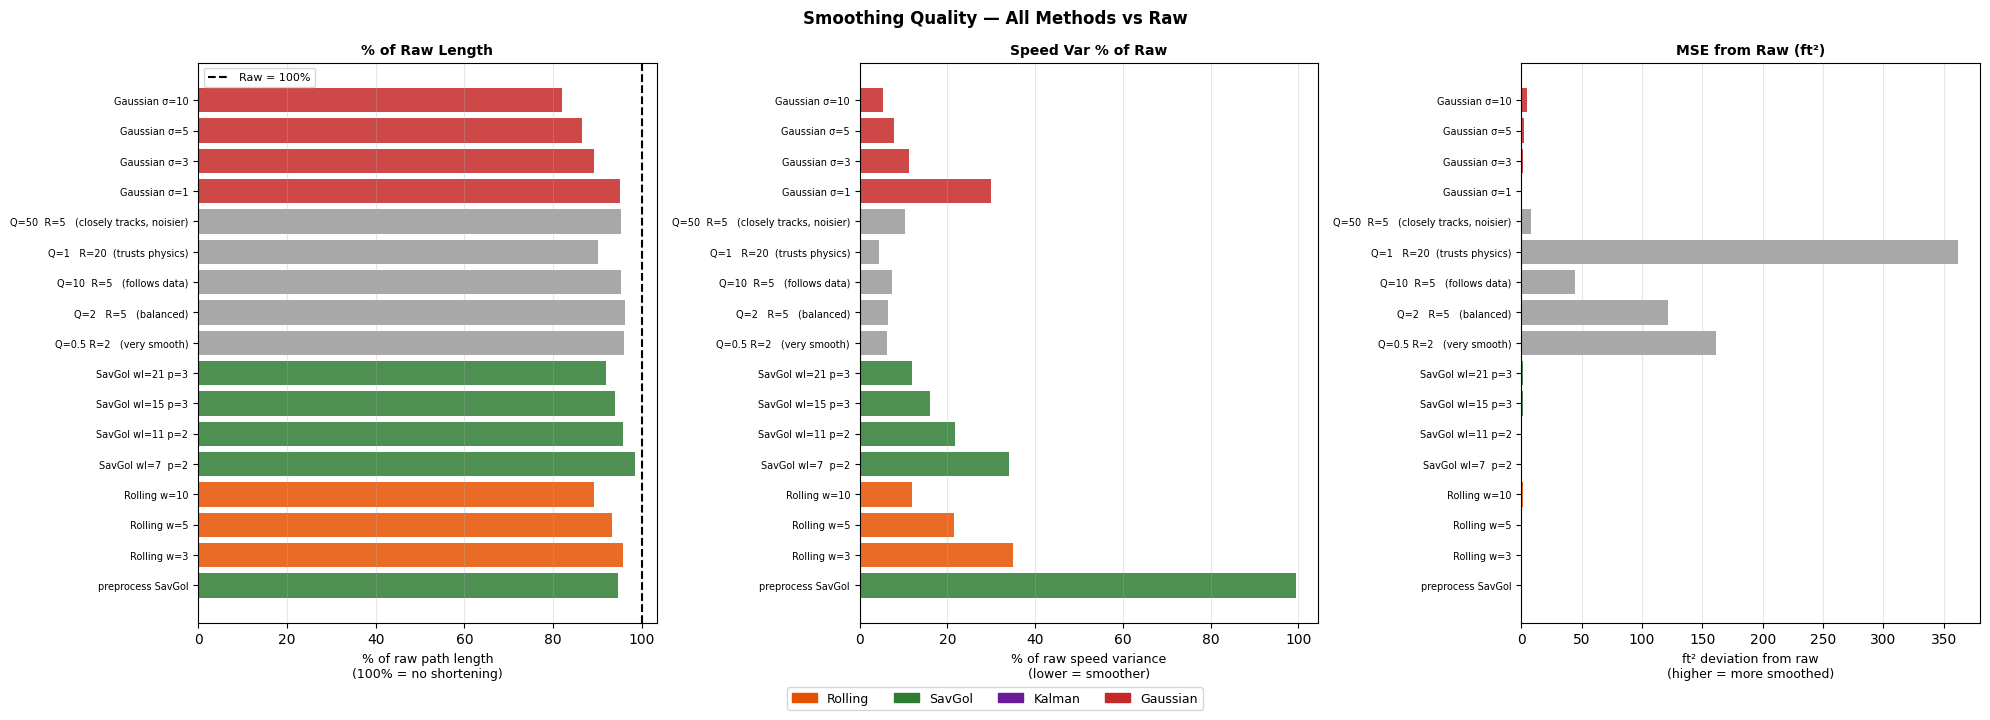

In [13]:
cat_colors = {'Rolling': '#E65100', 'SavGol': '#2E7D32', 'Kalman': '#6A1B9A', 'Gaussian': '#C62828', 'Raw': '#999999'}

def get_cat(name):
    for c in cat_colors:
        if c in name: return c
    return 'Raw'

non_raw = df[df['Method'] != 'Raw'].copy()
bar_colors = [cat_colors[get_cat(n)] for n in non_raw['Method']]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, metric, xlabel in zip(axes,
        ['% of Raw Length', 'Speed Var % of Raw', 'MSE from Raw (ft²)'],
        ['% of raw path length\n(100% = no shortening)', '% of raw speed variance\n(lower = smoother)', 'ft² deviation from raw\n(higher = more smoothed)']):
    ax.barh(non_raw['Method'], non_raw[metric], color=bar_colors, alpha=0.85)
    if '100' in xlabel:
        ax.axvline(100, color='black', linestyle='--', lw=1.5, label='Raw = 100%')
        ax.legend(fontsize=8)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

patches = [mpatches.Patch(color=c, label=cat) for cat, c in cat_colors.items() if cat != 'Raw']
fig.legend(handles=patches, fontsize=9, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03))
plt.suptitle('Smoothing Quality — All Methods vs Raw', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusions & Recommendation

**Summary of trade-offs:**

| Method | Pros | Cons |
|---|---|---|
| **Rolling mean** | Simple, fast | Blunts sharp turns; edge drift at window boundaries |
| **Savitzky-Golay** | Preserves peaks & direction changes; no lag; familiar (already used for speed) | Needs odd window length; slight overshoot at path ends |
| **Kalman filter** | Physically principled; gives smoothed velocity `(vx, vy)` for free; handles noise explicitly | Requires tuning Q and R; assumes constant-velocity between frames |
| **Gaussian** | Symmetric, no lag; intuitive σ parameter | Very similar to rolling mean; edge reflection artifacts |

**Recommendation for this project:**

- **For visualization (scenario notebooks):** `SavGol(window_length=11, polyorder=2)` applied to X and Y in `preprocess.py`. This is the cleanest option that preserves real skating direction changes and uses the same approach already proven for speed smoothing.

- **If velocity estimates are needed later:** the Kalman filter with `Q=2, R=5` is worth revisiting — it gives clean `(vx, vy)` from the filter state, which could replace the current speed computation entirely.

**Next step:** Add `x_smooth` and `y_smooth` columns to `preprocess.py` using SavGol, then use those columns in the scenario notebook plot functions instead of raw X/Y.